In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.model_selection import train_test_split

In [5]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

In [6]:
train.head()

,id,study_hours,sleep_hours,attendance_pct,previous_score,screen_time_hours,tutoring,parent_education,internet_access,extracurricular,school_type,exam_score
0,0,1.6,6.8,89.6,53.0,1.4,weekly,NaN,yes,no,private,57.1
1,1,0.5,6.5,98.0,86.0,1.6,weekly,postgraduate,yes,no,public,67.2
2,2,4.6,7.5,87.7,67.0,1.9,none,graduate,yes,yes,public,72.3
3,3,2.4,6.8,91.4,84.0,6.5,weekly,school,no,yes,public,67.7
4,4,2.4,5.2,80.5,43.0,1.8,none,school,no,no,private,38.9


In [7]:
train.describe()

,id,study_hours,sleep_hours,attendance_pct,previous_score,screen_time_hours,exam_score
count,7000.000000,7000.000000,6789.000000,7000.000000,7000.000000,6799.000000,7000.000000
mean,3499.500000,3.483314,6.815717,91.092914,63.961286,3.524048,57.907929
std,2020.870275,2.337637,1.190950,7.041620,13.967603,2.226025,9.735915
min,0.000000,0.100000,3.000000,46.100000,13.000000,0.000000,22.700000
25%,1749.750000,1.700000,6.000000,87.800000,55.000000,1.900000,51.500000
50%,3499.500000,3.000000,6.800000,92.900000,64.000000,3.100000,58.000000
75%,5249.250000,4.700000,7.600000,96.200000,73.000000,4.700000,64.400000
max,6999.000000,16.000000,10.000000,100.000000,100.000000,14.000000,100.000000


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7000 non-null   int64  
 1   study_hours        7000 non-null   float64
 2   sleep_hours        6789 non-null   float64
 3   attendance_pct     7000 non-null   float64
 4   previous_score     7000 non-null   float64
 5   screen_time_hours  6799 non-null   float64
 6   tutoring           7000 non-null   object 
 7   parent_education   6788 non-null   object 
 8   internet_access    7000 non-null   object 
 9   extracurricular    7000 non-null   object 
 10  school_type        7000 non-null   object 
 11  exam_score         7000 non-null   float64
dtypes: float64(6), int64(1), object(5)
memory usage: 656.4+ KB


In [9]:
train.isnull().sum()

,0
id,0
study_hours,0
sleep_hours,211
attendance_pct,0
previous_score,0
screen_time_hours,201
tutoring,0
parent_education,212
internet_access,0
extracurricular,0


#### **EDA**

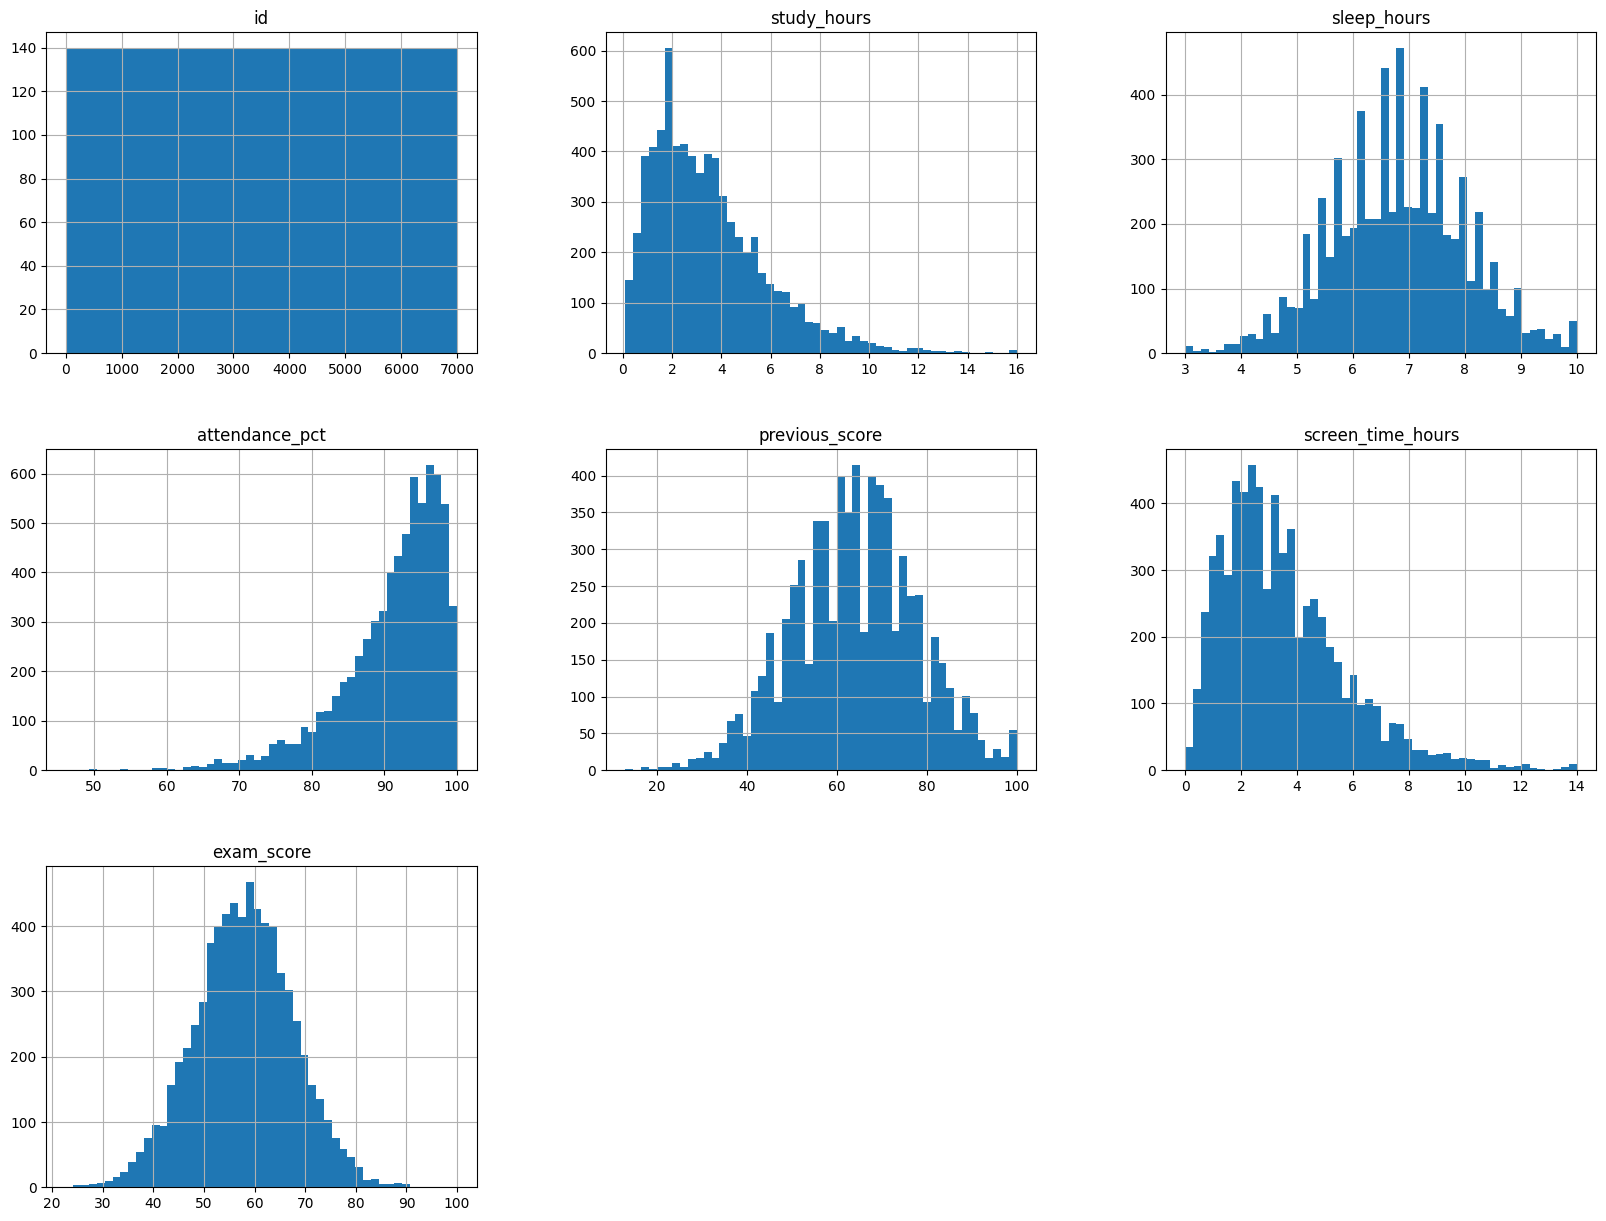

In [10]:
train.hist(bins = 50, figsize = (20,15))
plt.show()

We can observe the skewness in the features from the histogram above.

In [11]:
train['parent_education'].value_counts()

,count
parent_education,
school,2072
college,2043
graduate,1834
postgraduate,839


#### **Statistical Tests**

Checking dependence on the target column of the categorical columns

**Parent education column**

**1. ANOVA**

Let us check using Anova does the parent's education has any impact on the examination score of the student.

H0: the average exam score is the same for all 4 education groups.

H1: at least one group has a different average.

In [12]:
train1 = train.copy()

In [13]:
train1 = train1.dropna()
scipy.stats.f_oneway(train1[train1["parent_education"] == "school"]["exam_score"],
                      train1[train1["parent_education"] == "college"]["exam_score"],
                      train1[train1["parent_education"] == "graduate"]["exam_score"],
                      train1[train1["parent_education"] == "postgraduate"]["exam_score"])

F_onewayResult(statistic=np.float64(55.41211849571794), pvalue=np.float64(2.3605587112058388e-35))

Average exam scores differ across parent education groups (p < 0.05). This shows an association, not proof that parent education causes the difference

**Tutoring Column**

H0: the average exam score is the same for weekly, daily and no tutoring.

H1: at least one group has a different average.

In [14]:
train["tutoring"].value_counts()

,count
tutoring,
none,3858
weekly,2419
daily,723


In [15]:
scipy.stats.f_oneway(train1[train1["tutoring"] == "weekly"]["exam_score"],
                     train1[train1["tutoring"] == "daily"]["exam_score"],
                     train1[train1["tutoring"] == "none"]["exam_score"])


F_onewayResult(statistic=np.float64(119.81523832571601), pvalue=np.float64(8.249377000723195e-52))

ANOVA test is an omnibus test. It tells you that at least one pair of groups has significantly different mean exam scores, but it does not specify which pairs are different.• Since this value is vastly smaller than the standard significance level (α = 0.05), we reject the null hypothesis.
• The null hypothesis assumes that all groups have the same average exam score. Rejecting it provides strong evidence that mean exam scores differ across tutoring groups..

Having a large f statistic also shows that there is a variation between the three groups. So we can say that having tuitions has a impact on the score.


**Internet Access**

**2. T-test**

In [16]:

train["internet_access"].value_counts()

,count
internet_access,
yes,5769
no,1231


In [17]:
scipy.stats.ttest_ind(train1[train1["internet_access"] == "yes"]["exam_score"],
                      train1[train1["internet_access"] == "no"]["exam_score"], equal_var = False)

TtestResult(statistic=np.float64(6.951055180722798), pvalue=np.float64(5.226628320113725e-12), df=np.float64(1629.4374709355147))

we reject the null hypothesis, again there is a significant difference between the two classes and the variation is not due to chance.

**extra-curricular**

In [18]:
train["extracurricular"].value_counts()

,count
extracurricular,
no,3864
yes,3136


In [19]:
scipy.stats.ttest_ind(train1[train1["extracurricular"] == "yes"]["exam_score"],
                      train1[train1["extracurricular"] == "no"]["exam_score"], equal_var = False)

TtestResult(statistic=np.float64(3.2641254523266596), pvalue=np.float64(0.0011041125104570143), df=np.float64(6065.105700746147))

There is a impact of extracurricular acticities on exam - score

**School - type**

In [20]:
train["school_type"].value_counts()

,count
school_type,
public,4271
private,2729


In [21]:
scipy.stats.ttest_ind(train1[train1["school_type"] == "public"]["exam_score"],
                      train1[train1["school_type"] == "private"]["exam_score"], equal_var = False)

TtestResult(statistic=np.float64(-5.30102530425079), pvalue=np.float64(1.197918039372697e-07), df=np.float64(5332.397015350813))

There is a depencence observed here also.

**Correlation**

In [22]:
num = train.select_dtypes(include = "number")

<Axes: >

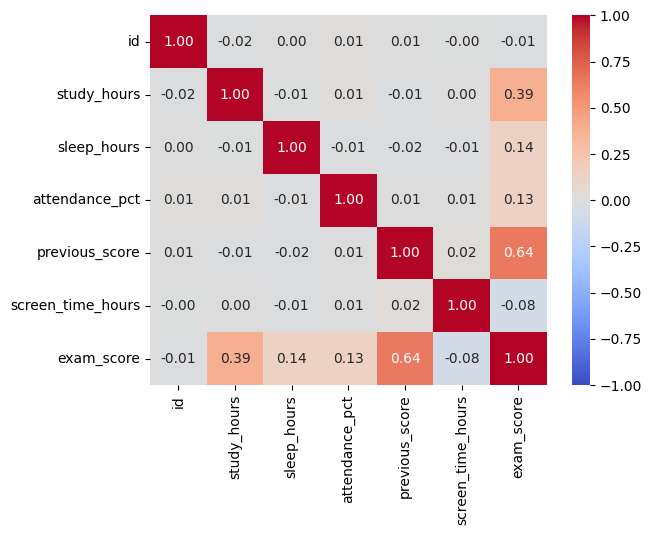

In [23]:
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

We can observe that there is slight dependence of studying hours, sleep hours on the score. There is a negative correlation due to screen_time and a strong positive correlation due to previous scores

In [24]:
train.columns

Index(['id', 'study_hours', 'sleep_hours', 'attendance_pct', 'previous_score',
       'screen_time_hours', 'tutoring', 'parent_education', 'internet_access',
       'extracurricular', 'school_type', 'exam_score'],
      dtype='object')

<Axes: ylabel='previous_score'>

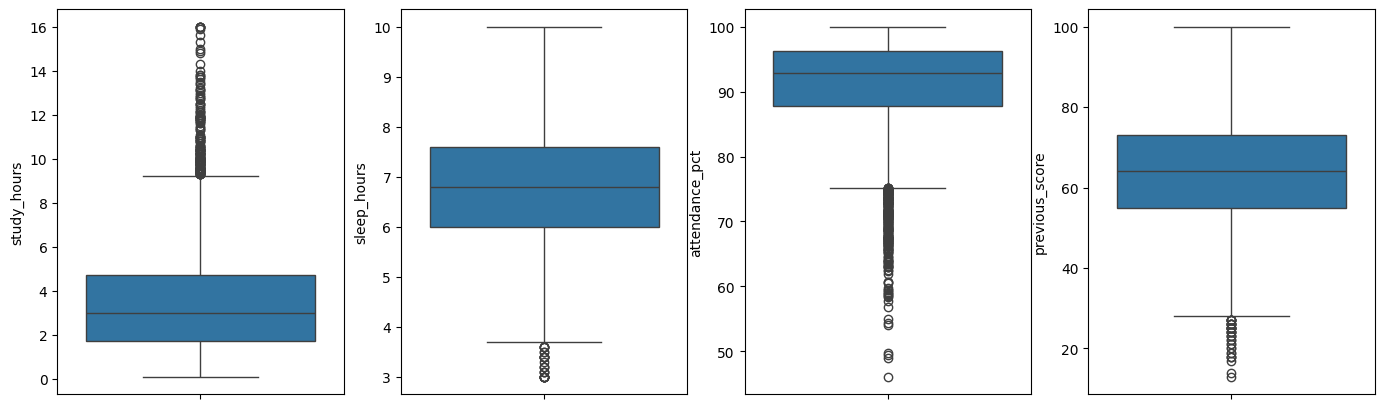

In [25]:
plt.figure(figsize = (17,5))
plt.subplot(141)
sns.boxplot(y = train["study_hours"])

plt.subplot(142)
sns.boxplot(y = train["sleep_hours"])

plt.subplot(143)
sns.boxplot(y = train["attendance_pct"])

plt.subplot(144)
sns.boxplot(y = train["previous_score"])

There are outliers in these columns.

#### **Data preprocessing**

In [26]:
# fixing inconsistent categories
train['extracurricular'] = train["extracurricular"].str.strip().str.lower()
train['tutoring'] = train["tutoring"].str.strip().str.lower()
train['parent_education'] = train["parent_education"].str.strip().str.lower()
train['internet_access'] = train["internet_access"].str.strip().str.lower()
train['school_type'] = train["school_type"].str.strip().str.lower()

In [27]:
train.duplicated().sum()

np.int64(0)

In [28]:
train["exam_score"].isnull().sum()

np.int64(0)

In [29]:
x = train
y = train["exam_score"]
x_test = test.copy()

In [30]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.2, random_state=42)

In [31]:
from sklearn.impute import SimpleImputer

In [32]:
train.isnull().sum()

,0
id,0
study_hours,0
sleep_hours,211
attendance_pct,0
previous_score,0
screen_time_hours,201
tutoring,0
parent_education,212
internet_access,0
extracurricular,0


In [33]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score


trf = ColumnTransformer(transformers = [
    ("num", SimpleImputer(strategy = "median"), ["sleep_hours","screen_time_hours"]),
    ("cat", SimpleImputer(strategy = "most_frequent"), ["parent_education"])
], remainder = "passthrough")

# Transform x_train and x_val
x_train = trf.fit_transform(x_train)
x_val = trf.transform(x_val)

In [34]:
feature_names = trf.get_feature_names_out()

In [35]:
x_train = pd.DataFrame(x_train, columns = feature_names)
x_val = pd.DataFrame(x_val, columns = feature_names)

In [36]:
x_train.head()

,num__sleep_hours,num__screen_time_hours,cat__parent_education,remainder__id,remainder__study_hours,remainder__attendance_pct,remainder__previous_score,remainder__tutoring,remainder__internet_access,remainder__extracurricular,remainder__school_type,remainder__exam_score
0,6.3,2.0,postgraduate,1032,0.9,88.4,94.0,none,yes,no,public,68.3
1,8.3,3.1,school,6339,6.4,82.6,55.0,none,no,no,public,47.8
2,7.4,4.7,college,3886,2.6,99.3,74.0,none,yes,yes,private,62.2
3,4.5,3.5,college,2653,4.2,98.3,46.0,none,yes,yes,private,46.1
4,5.6,2.4,school,6914,0.7,78.7,82.0,daily,yes,yes,public,63.1


In [37]:
column_name_mapping = {}
for new_name in feature_names:
    original_name = new_name.split('__')[-1]
    column_name_mapping[new_name] = original_name

print(column_name_mapping)

{'num__sleep_hours': 'sleep_hours', 'num__screen_time_hours': 'screen_time_hours', 'cat__parent_education': 'parent_education', 'remainder__id': 'id', 'remainder__study_hours': 'study_hours', 'remainder__attendance_pct': 'attendance_pct', 'remainder__previous_score': 'previous_score', 'remainder__tutoring': 'tutoring', 'remainder__internet_access': 'internet_access', 'remainder__extracurricular': 'extracurricular', 'remainder__school_type': 'school_type', 'remainder__exam_score': 'exam_score'}


In [38]:
x_train = x_train.rename(columns = column_name_mapping)
x_val = x_val.rename(columns = column_name_mapping)

**Feature Extraction**

Model is not performing well, let us try more data preprocessing so that we can improve on the scores. We can do this by extracting more features from the existing features so that we could highlight more upon the patterns that are hidden.

A strong academic focus would naturally improve the scores and this will mean that a student is spending more time on studying and having quality sleep and the screen time is lesser.

In [39]:
x_train.info()
num_cols = ["sleep_hours","screen_time_hours", "study_hours", "attendance_pct","previous_score","exam_score"]
cat_cols = ["parent_education", "tutoring", "internet_access", "school_type", "extracurricular"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5600 entries, 0 to 5599
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sleep_hours        5600 non-null   object
 1   screen_time_hours  5600 non-null   object
 2   parent_education   5600 non-null   object
 3   id                 5600 non-null   object
 4   study_hours        5600 non-null   object
 5   attendance_pct     5600 non-null   object
 6   previous_score     5600 non-null   object
 7   tutoring           5600 non-null   object
 8   internet_access    5600 non-null   object
 9   extracurricular    5600 non-null   object
 10  school_type        5600 non-null   object
 11  exam_score         5600 non-null   object
dtypes: object(12)
memory usage: 525.1+ KB


In [40]:
for col in num_cols:
    if col in x_train.columns:
        x_train[col] = pd.to_numeric(x_train[col])
    if col in x_val.columns:
        x_val[col] = pd.to_numeric(x_val[col])

In [41]:
import numpy as np
x_train['screen_to_study_ratio'] = np.log1p(x_train['screen_time_hours'] / x_train['study_hours'])
x_val["screen_to_study_ratio"] = np.log1p(x_val["screen_time_hours"] / x_val["study_hours"])


<Axes: xlabel='screen_to_study_ratio', ylabel='exam_score'>

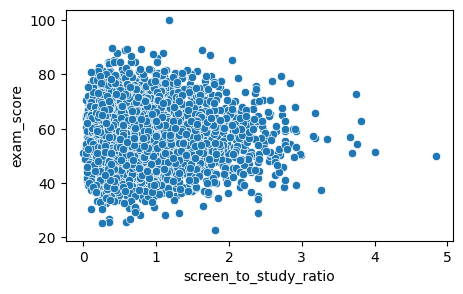

In [42]:
plt.figure(figsize = (5,3))
sns.scatterplot(x = x_train["screen_to_study_ratio"], y = y_train)

In [43]:
x_train["screen_to_study_ratio"].corr(y_train)

np.float64(-0.01568177641149734)

We can observe a high negative correlation.

**Academic Focus Index**

In [44]:
x_train["Academic_focus_index"] = (x_train["study_hours"] * x_train["sleep_hours"])/(x_train["study_hours"]+x_train["screen_time_hours"])
x_val["Academic_focus_index"] = (x_val["study_hours"] * x_val["sleep_hours"])/(x_val["study_hours"]+x_val["screen_time_hours"])

<Axes: xlabel='Academic_focus_index', ylabel='exam_score'>

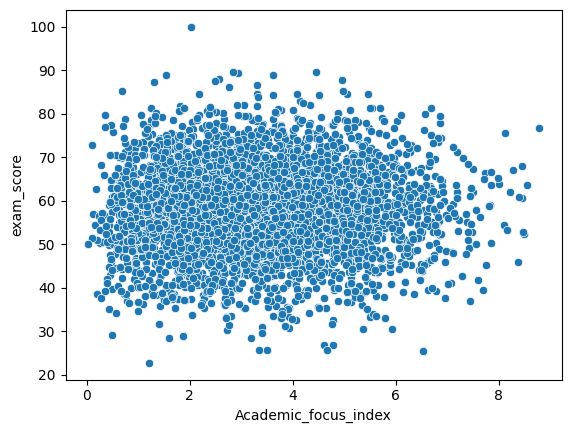

In [45]:
sns.scatterplot(x = x_train["Academic_focus_index"], y = y_train)

**Cognitive Friction**

In human-computer interaction (HCI) and behavioral science, cognitive friction refers to the mental effort required by a user to complete a task when a system or routine doesn't match their natural expectations.
When applied to your student dataset, Cognitive Friction serves as the ultimate metric for "mental resistance." It represents how hard a student's brain has to work to overcome digital distractions and sleep deprivation just to focus on their studies.

In [46]:
x_train.columns

Index(['sleep_hours', 'screen_time_hours', 'parent_education', 'id',
       'study_hours', 'attendance_pct', 'previous_score', 'tutoring',
       'internet_access', 'extracurricular', 'school_type', 'exam_score',
       'screen_to_study_ratio', 'Academic_focus_index'],
      dtype='object')

In [47]:
x_train["cognitive_friction"] = np.log1p(x_train["screen_to_study_ratio"]/x_train["Academic_focus_index"])
x_val["cognitive_friction"] = np.log1p(x_val["screen_to_study_ratio"]/x_val["Academic_focus_index"])

Cognitive Friction, successfully captures the compounding psychological toll of digital distraction on a sleep-deprived brain. The data proves that sleep deprivation and screen time do not penalize students independently. Instead, they act as a multiplier: when a student enters a sleep deficit, their resilience to digital distraction collapses, scaling their Cognitive Friction exponentially


**Attendance and performance metric**

In [48]:
x_train['academic_engagement'] = x_train['study_hours'] * (x_train['attendance_pct'] / 100)
x_val['academic_engagement'] = x_val['study_hours'] * (x_val['attendance_pct'] / 100)

**Identify students with high past performance who are currently skipping class or not studying, vs. those with lower past performance who are working incredibly hard.**

In [49]:
x_train['efficiency_index'] = x_train['previous_score'] / (x_train['study_hours'] + 0.1)
x_val['efficiency_index'] = x_val['previous_score'] / (x_val['study_hours'] +0.1)

In [50]:
num = x_train.select_dtypes(include = "number")

<Axes: >

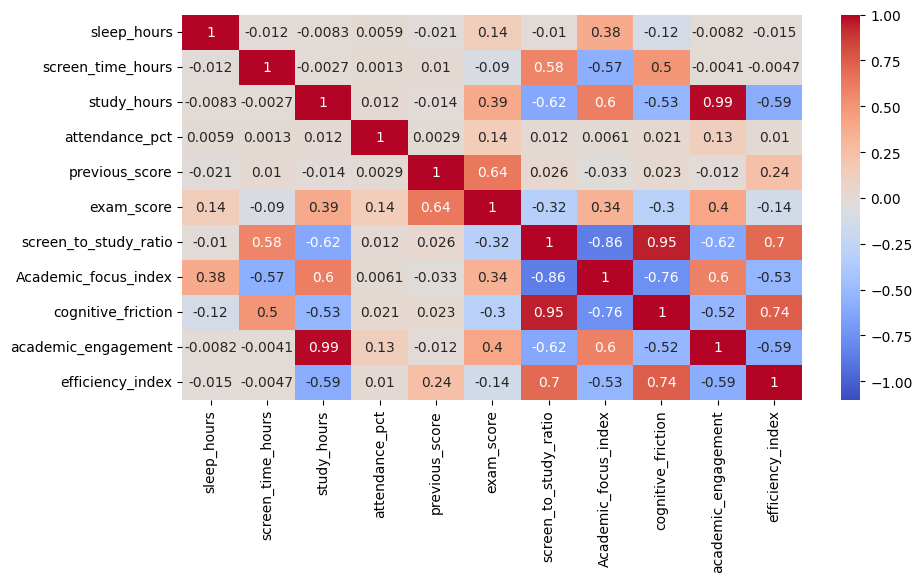

In [51]:
plt.figure(figsize=(10,5))
sns.heatmap(num.corr(), annot = True, cmap = "coolwarm", vmax=-1, vmin =1)

In [52]:
np.linalg.det(num.corr())

np.float64(5.420590508690747e-08)

Shows high multicollinearity, dropping some redundant features is required

**Dropping redundant columns**

In [53]:
# Columns that are too highly correlated with each other
cols_to_drop = ['cognitive_friction', 'Academic_focus_index']

# Drop them safely from both splits
x_train = x_train.drop(columns=cols_to_drop)
x_val = x_val.drop(columns = cols_to_drop)

In [54]:
num = x_train.select_dtypes(include = "number")
np.linalg.det(num.corr())

np.float64(0.00010699453807439599)

In [55]:
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

#### **Model Fitting**

In [56]:
print(num.skew())

sleep_hours              0.015545
screen_time_hours        1.221924
study_hours              1.283119
attendance_pct          -1.495916
previous_score          -0.042247
exam_score              -0.033326
screen_to_study_ratio    1.344453
academic_engagement      1.344547
efficiency_index         4.064623
dtype: float64


In [57]:


x_train = x_train.drop(["exam_score","id"], axis = 1)

In [58]:
x_val = x_val.drop(["exam_score","id"], axis = 1)

In [59]:
x_train.columns

Index(['sleep_hours', 'screen_time_hours', 'parent_education', 'study_hours',
       'attendance_pct', 'previous_score', 'tutoring', 'internet_access',
       'extracurricular', 'school_type', 'screen_to_study_ratio',
       'academic_engagement', 'efficiency_index'],
      dtype='object')

In [60]:
num_cols = ["sleep_hours", "screen_to_study_ratio", "academic_engagement", "efficiency_index",'screen_time_hours',"previous_score","attendance_pct","study_hours"]
cat_cols = ["parent_education","internet_access","extracurricular","school_type","tutoring"]

In [61]:
ord_order = [
    ["school", "college", "graduate", "postgraduate"],   # parent_education
    ["none", "weekly", "daily"],                         # tutoring
]

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ("pt", PowerTransformer(method="yeo-johnson"), num_cols),
        ("ohe", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), ["internet_access", "extracurricular", "school_type"]),
        ("ord", OrdinalEncoder(categories=ord_order, handle_unknown="use_encoded_value", unknown_value=-1), ["parent_education", "tutoring"]),
        ("std", StandardScaler(), num_cols)
    ]
)

In [63]:
step = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)

pipe = Pipeline([("preprocessor",preprocessor),('step', step)])
pipe.set_output(transform="pandas")


pipe.fit(x_train, y_train)
y_val_pred = pipe.predict(x_val)

r2_score(y_val, y_val_pred)

0.6537714977407749

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

In [65]:
param_dist = {
    "step__n_estimators": [100, 200, 300, 500],
    "step__max_depth": [10, 15, 20, 25, None],
    "step__min_samples_split": [2, 5, 10],
    "step__min_samples_leaf": [1, 2, 4],
    "step__max_features": [0.5, 0.75, "sqrt", "log2"],
    "step__max_samples": [0.5, 0.7, 0.9, None]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train, y_train)
best_pipe = search.best_estimator_
y_val_pred = best_pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
R2 score 0.6578265911631658
MAE 4.339144727892478


**Linear Regression**

In [66]:
step_lr = LinearRegression()
pipe_lr = Pipeline([("preprocessor",preprocessor), ('step_lr', step_lr)])

pipe_lr.fit(x_train, y_train)
y_val_pred_lr = pipe_lr.predict(x_val)

print("R2 score for Linear Regression:", r2_score(y_val, y_val_pred_lr))
print("MAE for Linear Regression:", mean_absolute_error(y_val, y_val_pred_lr))

R2 score for Linear Regression: 0.7042902935219275
MAE for Linear Regression: 4.091377143411786


In [67]:
from sklearn.linear_model import Lasso, Ridge

**Lasso Regression**

In [68]:
step3 = Lasso()
pipe = Pipeline([("preprocessor",preprocessor), ('step3', step3)])

pipe.fit(x_train, y_train)
y_val_pred = pipe.predict(x_val)

print("R2 score for Linear Regression:", r2_score(y_val, y_val_pred))
print("MAE for Linear Regression:", mean_absolute_error(y_val, y_val_pred))

R2 score for Linear Regression: 0.59381698760737
MAE for Linear Regression: 4.7835178990549165


**Ridge regression**

In [69]:
step3 = Ridge(0.001)
pipe = Pipeline([ ("preprocessor",preprocessor),('step3', step3)])

pipe.fit(x_train, y_train)
y_val_pred = pipe.predict(x_val)

print("r2_score",r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

r2_score 0.7042002349569926
MAE 4.093361322324771


**Gradient boosting**

In [70]:
step3 = GradientBoostingRegressor(learning_rate=0.03, n_estimators=600, max_depth=2 or 3, subsample=0.7)
pipe = Pipeline([("preprocessor",preprocessor), ('step3', step3)])

pipe.fit(x_train, y_train)
y_val_pred = pipe.predict(x_val)

print("r2_score",r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

r2_score 0.6976364163102198
MAE 4.12298713475977


**Stacking**

In [71]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error

base = [
    ("lr", LinearRegression()),
    ("rf", RandomForestRegressor(n_estimators = 300, min_samples_leaf = 4,
                                 max_features = 0.75, random_state = 42, n_jobs = -1)),
    ("gb", GradientBoostingRegressor(n_estimators = 300, learning_rate = 0.05,
                                     max_depth = 3, subsample = 0.8, random_state = 42)),
]

stack = StackingRegressor(estimators = base, final_estimator = RidgeCV(), cv = 5, n_jobs = -1)

pipe_stack = Pipeline([("preprocessor",preprocessor), ('step', stack)])

pipe_stack.fit(x_train, y_train)
y_val_pred_st = pipe_stack.predict(x_val)

print("R2 stacking:", r2_score(y_val, y_val_pred_st))
print("MAE stacking:", mean_absolute_error(y_val, y_val_pred_st))

R2 stacking: 0.7042399149604548
MAE stacking: 4.090333322255124


**SVM**

In [72]:

from sklearn.svm import SVR

step3 = SVR(kernel = "rbf")
pipe = Pipeline([("preprocessor",preprocessor), ('step3', step3)])

pipe.fit(x_train, y_train)
y_val_pred = pipe.predict(x_val)

print("r2_score",r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

r2_score 0.665285712466381
MAE 4.331358385936467


## **Conclusion**

Finally, we can observe that adding new features to the data was of no help, the models are unable to capture the underlying pattern. The data has a lot of random noise. So, the final model and the dataset that should be worked upon is as follows:

In [73]:
num_cols = ["sleep_hours",'screen_time_hours',"previous_score","attendance_pct","study_hours"]
cat_cols = ["parent_education","internet_access","extracurricular","school_type","tutoring"]

In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        ("pt", PowerTransformer(method="yeo-johnson"), num_cols),
        ("ohe", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), ["internet_access", "extracurricular", "school_type"]),
        ("ord", OrdinalEncoder(categories=ord_order, handle_unknown="use_encoded_value", unknown_value=-1), ["parent_education", "tutoring"]),
        ("std", StandardScaler(), num_cols)
    ]
)

In [108]:

x_train_final = x_train.drop(["screen_to_study_ratio",'academic_engagement', "efficiency_index"], axis = 1)
x_val_final = x_val.drop(["screen_to_study_ratio",'academic_engagement', "efficiency_index"], axis = 1)

In [76]:
x_val.columns

Index(['sleep_hours', 'screen_time_hours', 'parent_education', 'study_hours',
       'attendance_pct', 'previous_score', 'tutoring', 'internet_access',
       'extracurricular', 'school_type', 'screen_to_study_ratio',
       'academic_engagement', 'efficiency_index'],
      dtype='object')

**Linear Regression**

In [77]:
from sklearn.model_selection import GridSearchCV

In [78]:
step_lr = LinearRegression()
pipe_lr = Pipeline([("preprocessor",preprocessor), ('step_lr', step_lr)])

pipe_lr.fit(x_train_final, y_train)
y_val_pred_lr = pipe_lr.predict(x_val_final)

print("R2 score for Linear Regression:", r2_score(y_val, y_val_pred_lr))
print("MAE for Linear Regression:", mean_absolute_error(y_val, y_val_pred_lr))

R2 score for Linear Regression: 0.7041273503609045
MAE for Linear Regression: 4.0900633134954


**Ridge regression**

In [79]:
step3 = Ridge(alpha = 0.001)
pipe = Pipeline([("preprocessor",preprocessor),('step3', step3)])

pipe.fit(x_train_final, y_train)
y_val_pred = pipe.predict(x_val_final)

print("r2_score",r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

r2_score 0.7040483890032738
MAE 4.092030902390113


<Axes: >

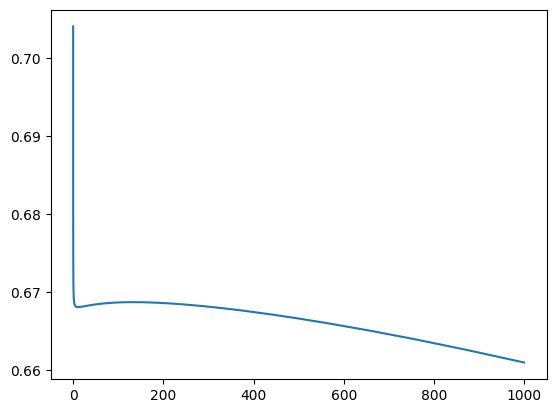

In [80]:
a_values = np.logspace(-3,3,100)
mae = []
for i in a_values:
  pipe.set_params(step3__alpha=i)
  pipe.fit(x_train_final,y_train)
  y_pred = pipe.predict(x_val)
  mae.append(r2_score(y_val,y_pred))
sns.lineplot(x = a_values, y = mae)

In [81]:
param_grid = {
    'step3__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,                             # 5-fold cross-validation
    scoring='r2',                     # Optimizes for the best R2 score
    n_jobs=-1                         # Uses all available CPU cores
)

grid_search.fit(x_train_final, y_train)

print("Best parameters found:", grid_search.best_params_)

y_val_pred = grid_search.predict(x_val_final)

print("Optimized r2_score:", r2_score(y_val, y_val_pred))
print("Optimized MAE:", mean_absolute_error(y_val, y_val_pred))

Best parameters found: {'step3__alpha': 0.001}
Optimized r2_score: 0.7040483890032738
Optimized MAE: 4.092030902390113


In [82]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error
print("mse",mean_squared_error(y_val, y_val_pred))
print("rmse", root_mean_squared_error(y_val, y_val_pred))

mse 26.958802622963955
rmse 5.192186689918223


In [83]:
r2_score(y_train, grid_search.predict(x_train_final))

0.7301350946022227

**SVR**

In [ ]:
from sklearn.svm import SVR

step3 = SVR(kernel = "rbf")
pipe = Pipeline([("preprocessor",preprocessor), ('step3', step3)])

pipe.fit(x_train_final, y_train)
y_val_pred = pipe.predict(x_val_final)

print("r2_score",r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

r2_score 0.6653855307535126
MAE 4.332194488130766


In [ ]:
param_grid = {
    'step3__kernel': ['linear', 'rbf'],
    'step3__C': [0.1, 1.0, 10.0, 100.0],
    'step3__epsilon': [0.01, 0.1, 0.2, 0.5],
    'step3__gamma': ['scale', 'auto']
}

# 3. Setup Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 4. Run the tuning on your training data
grid_search.fit(x_train_final, y_train)

# 5. Print the optimized settings found
print("Best Parameters:", grid_search.best_params_)

# 6. Predict and print validation metrics
y_val_pred = grid_search.predict(x_val_final)
print("Optimized SVR r2_score:", r2_score(y_val, y_val_pred))
print("Optimized SVR MAE:", mean_absolute_error(y_val, y_val_pred))


Best Parameters: {'step3__C': 100.0, 'step3__epsilon': 0.2, 'step3__gamma': 'scale', 'step3__kernel': 'linear'}
Optimized SVR r2_score: 0.6852414488467096
Optimized SVR MAE: 4.243315936359821


**LGBM**

In [84]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [85]:
step3 = LGBMRegressor()
pipe = Pipeline([ ("preprocessor",preprocessor),('step3', step3)])

pipe.fit(x_train_final, y_train)
y_val_pred = pipe.predict(x_val_final)

print("r2_score",r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1172
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 15
[LightGBM] [Info] Start training from score 57.884625
r2_score 0.665645141623839
MAE 4.336940008588897


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [86]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

# 1. Re-initialize standard LightGBM
step3 = LGBMRegressor(random_state=42, verbose=-1)
pipe = Pipeline([("preprocessor", preprocessor), ('step3', step3)])

params = {
    'step3__n_estimators':[100,200,300],
    'step3__learning_rate': [0.03, 0.05, 0.1],
    'step3__max_depth': [3, 5, -1],           # -1 means no limit
    'step3__num_leaves': [15, 31, 63]
}

# 3. Setup Grid Search
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 4. Fit and check results
grid_search.fit(x_train_final, y_train)

print("Best Parameters:", grid_search.best_params_)
y_val_pred = grid_search.predict(x_val_final)
print("Tuned LGBM Validation R²:", r2_score(y_val, y_val_pred))
print("Tuned LGBM Validation MAE:", mean_absolute_error(y_val, y_val_pred))


Best Parameters: {'step3__learning_rate': 0.1, 'step3__max_depth': 3, 'step3__n_estimators': 200, 'step3__num_leaves': 15}
Tuned LGBM Validation R²: 0.6876096048570697
Tuned LGBM Validation MAE: 4.2051689909787635


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**Using ridge(0.001) as the final model**

In [87]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Step 1: Freshly reload the data to clean up the notebook's memory
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Step 2: Super simple cleanup loop (fixes all NaN/missing values instantly)
for col in train.columns:
    if train[col].dtype == 'object':
        # If it's text data, fill missing values with the most common word
        train[col] = train[col].fillna(train[col].mode()[0])
        if col in test.columns:
            test[col] = test[col].fillna(train[col].mode()[0])
    else:
        # If it's numerical data, fill missing values with the median number
        train[col] = train[col].fillna(train[col].median())
        if col in test.columns:
            test[col] = test[col].fillna(train[col].median())

# Step 3: Separate features and targets (keeping all column names perfectly intact)
x_train_w = train.drop(["exam_score", "id"], axis=1)
y_train_w = train["exam_score"]
x_test_w = test.drop(["id"], axis=1)

# Step 4: Re-link your existing preprocessor to the model pipeline
step3 = Ridge(alpha=0.001)
pipe = Pipeline([("preprocessor", preprocessor), ('step3', step3)])

# Step 5: Fit the model and make predictions
pipe.fit(x_train_w, y_train_w)
ypred = pipe.predict(x_test_w)


In [88]:
submission = pd.DataFrame({"id": test["id"], "exam_score":ypred})
submission.to_csv("submission.csv", index = False)

### Neural Network

In [89]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [90]:
model = Sequential()

In [94]:
x_train.shape

(5600, 13)

In [127]:
# 1. Transform raw features using the preprocessor (produces 15 columns due to One-Hot Encoding)
x_train_transformed = preprocessor.fit_transform(x_train_final)
x_val_transformed = preprocessor.transform(x_val_final)

# 2. Re-initialize and compile the Sequential model with matching input dimensions (15)
model = Sequential()
model.add(Dense(units=32, activation="relu", input_shape=(15,)))
model.add(Dense(units=32, activation="relu"))
model.add(Dense(units=16, activation="relu"))
model.add(Dense(units=1, activation="linear"))
model.compile(loss="mse", optimizer="adam", metrics=["mae", "r2_score"])

# 3. Fit the neural network on the transformed numeric data
history = model.fit(x_train_transformed, y_train, validation_data=(x_val_transformed, y_val), epochs=50, batch_size=32)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1263.9352 - mae: 28.8009 - r2_score: -12.2085 - val_loss: 166.2470 - val_mae: 10.2955 - val_r2_score: -0.8251
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 135.5575 - mae: 9.3084 - r2_score: -0.4166 - val_loss: 114.2891 - val_mae: 8.4808 - val_r2_score: -0.2547
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 94.4123 - mae: 7.6915 - r2_score: 0.0134 - val_loss: 80.2120 - val_mae: 7.1173 - val_r2_score: 0.1194
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 65.7630 - mae: 6.3908 - r2_score: 0.3128 - val_loss: 56.2918 - val_mae: 5.9675 - val_r2_score: 0.3820
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 48.2485 - mae: 5.4842 - r2_score: 0.4958 - val_loss: 43.4591 - val_mae: 5.2464 - val_r2_score: 0.5229
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 38.6177 - mae: 4.9186 - r2_score: 0.5964 - val_loss: 37.1550 - val_mae: 4.8448 - val_r2_score: 0.5921
Epoch 7/50
175/175 ━━━━━━━━

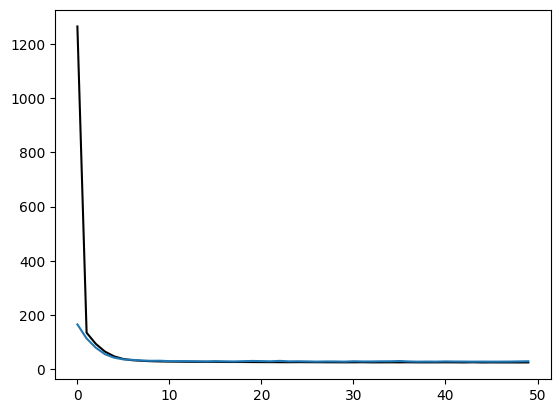

In [128]:
plt.plot(history.history["loss"],color = "black")
plt.plot(history.history["val_loss"])